# **MNIST Classification using FCNN and CNN in PyTorch**
--------------------------------------------------
This tutorial demonstrates how to:

* Load and preprocess the MNIST dataset
* Build two models - FCNN and CNN
* Train and evaluate the models
* Save and load trained models
* Compute confusion matrix, precision, recall, and F1-score
* Plot training loss vs epochs




# **1. IMPORT LIBRARIES**

In [1]:
import os
import cv2
import numpy as np
import seaborn as sns
import random as rand
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report

import torch
from torch import nn, optim, Tensor
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset

import torchvision
from torchvision import transforms

# **2. SETUP**

In [2]:
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
NUM_EPOCHS = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

Using device: cuda


# **3. LOAD AND PREPROCESS MNIST DATA**

In [3]:
class MNIST(Dataset):
    def __init__(
            self, 
            num_labels:int, 
            channel:int,
            img_pre_process=None, 
            path_dir:str="MNIST/Images/train", 
            file_ext:str=".jpg"
        )->None:
        super().__init__()
        if channel==1 or channel==3:
            self.channel=channel 
            self.path_dir = path_dir
            self.num_labels = num_labels
            self.img_pre_process = img_pre_process if img_pre_process is not None else transforms.Compose([
                                                                                            transforms.Normalize((0.1307,), (0.3081,))
                                                                                        ])

            if not self.verify_dir():
                raise FileNotFoundError("Unable to find the labels in MNIST")
            
            self.img_path = glob(os.path.join(self.path_dir, f"**/*{file_ext}"))
            self.label = {label:tag for tag, label in enumerate(os.listdir(self.path_dir))}
        else:
            raise ValueError(f"Channel count can only be 1 or 3 not {channel}")
        
    def verify_dir(self,)->bool:
        path_dir = os.listdir(self.path_dir)
        if len(path_dir)==self.num_labels:
            return True
        else:
            return False
    
    def __len__(self):
        return len(self.img_path)
    
    def load_image(self, path:str)->Tensor:
        if not os.path.exists(path):
            raise FileNotFoundError(f"Unable to find the image at path {path}")
        img = cv2.imread(path)
        if self.channel==1:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = img/255.0
            img_tensor = torch.from_numpy(img).to(torch.float32)
            img_tensor = torch.unsqueeze(img_tensor, dim=0)

        elif self.channel==3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img/255.0
            size_image = img.shape[0]
            img_tensor = torch.from_numpy(img).to(torch.float32)
            img_tensor = img_tensor.reshape([self.channel, size_image, size_image])

        return self.img_pre_process(img_tensor)

    def __getitem__(self, idx):
        path = self.img_path[idx]
        img_tensor = self.load_image(path)
        label = self.label[path.split("/")[-2]]
        label = torch.tensor(label).to(torch.long)
        return img_tensor, label
        

In [4]:
imageNet_transform = transforms.Compose([
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = MNIST(channel=3, num_labels=10, path_dir="tiny-imagenet/train", file_ext=".JPEG", img_pre_process=imageNet_transform)
test_dataset  = MNIST(channel=3, num_labels=10, path_dir="tiny-imagenet/test", file_ext=".JPEG", img_pre_process=imageNet_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Training samples: {len(train_dataset)}")
print(f"✅ Testing samples : {len(test_dataset)}")

✅ Training samples: 3500
✅ Testing samples : 1000


# **4. MODEL DEFINITIONS**

In [5]:
class FCNN(nn.Module):
    def __init__(self, input_size=64*64*3, num_classes=10):
        super(FCNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class SimpleCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(16384, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# **5. TRAINING AND TESTING FUNCTIONS**

In [6]:
def train_model(model, train_loader, optimizer, epoch):
    """Train model for one epoch and return average loss"""
    model.train()
    running_loss = 0.0
    for data, target in tqdm(train_loader):
        data, target = data.to(DEVICE), target.to(DEVICE)
        optimizer.zero_grad()
        output = model(data)
        loss = F.cross_entropy(output, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    print(f"🧠 Epoch [{epoch}] - Train Loss: {avg_loss:.4f}")
    return avg_loss

@torch.no_grad()
def test_model(model, test_loader):
    """Evaluate model and compute accuracy"""
    model.eval()
    test_loss, correct = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for data, target in tqdm(test_loader):
            data, target = data.to(DEVICE), target.to(DEVICE)
            output = model(data)
            test_loss += F.cross_entropy(output, target, reduction='sum').item()
            preds = output.argmax(dim=1)
            correct += preds.eq(target).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(target.cpu().numpy())
    test_loss /= len(test_loader.dataset)
    acc = 100. * correct / len(test_loader.dataset)
    print(f"✅ Test Loss: {test_loss:.4f} | Accuracy: {acc:.2f}%")
    return acc, np.array(all_preds), np.array(all_labels)

# **6. TRAIN FCNN MODEL**

In [7]:
print("\n===============================")
print("🚀 TRAINING FCNN MODEL")
print("===============================")

fcnn_model = FCNN().to(DEVICE)
fcnn_optimizer = optim.Adam(fcnn_model.parameters(), lr=LEARNING_RATE)
fcnn_losses = []

for epoch in range(1, NUM_EPOCHS + 1):
    loss = train_model(fcnn_model, train_loader, fcnn_optimizer, epoch)
    fcnn_losses.append(loss)

torch.save(fcnn_model.state_dict(), "fcnn_mnist.pth")
print("💾 FCNN model saved as 'fcnn_mnist.pth'")

fcnn_acc, fcnn_preds, fcnn_labels = test_model(fcnn_model, test_loader)


🚀 TRAINING FCNN MODEL


100%|██████████| 110/110 [00:01<00:00, 82.06it/s] 


🧠 Epoch [1] - Train Loss: 1.8288


100%|██████████| 110/110 [00:01<00:00, 103.13it/s]


🧠 Epoch [2] - Train Loss: 1.3840


...

🧠 Epoch [19] - Train Loss: 0.0869


100%|██████████| 110/110 [00:00<00:00, 141.69it/s]


🧠 Epoch [20] - Train Loss: 0.0998
💾 FCNN model saved as 'fcnn_mnist.pth'


100%|██████████| 32/32 [00:00<00:00, 193.02it/s]

✅ Test Loss: 4.2691 | Accuracy: 41.40%


# **7. TRAIN CNN MODEL**

In [ ]:
print("\n===============================")
print("🚀 TRAINING CNN MODEL")
print("===============================")

cnn_model = SimpleCNN().to(DEVICE)
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=LEARNING_RATE)
cnn_losses = []

for epoch in range(1, NUM_EPOCHS + 1):
    loss = train_model(cnn_model, train_loader, cnn_optimizer, epoch)
    cnn_losses.append(loss)

# Save CNN model
torch.save(cnn_model.state_dict(), "cnn_mnist.pth")
print("💾 CNN model saved as 'cnn_mnist.pth'")

# Evaluate CNN
cnn_acc, cnn_preds, cnn_labels = test_model(cnn_model, test_loader)


🚀 TRAINING CNN MODEL


100%|██████████| 110/110 [00:00<00:00, 127.11it/s]


🧠 Epoch [1] - Train Loss: 2.0407


100%|██████████| 110/110 [00:00<00:00, 131.57it/s]


🧠 Epoch [2] - Train Loss: 1.7358


...

🧠 Epoch [19] - Train Loss: 0.0517


100%|██████████| 110/110 [00:00<00:00, 126.64it/s]


🧠 Epoch [20] - Train Loss: 0.0608
💾 CNN model saved as 'cnn_mnist.pth'


100%|██████████| 32/32 [00:00<00:00, 190.61it/s]

✅ Test Loss: 3.7732 | Accuracy: 35.70%


# **8. PLOT EPOCH VS LOSS CURVES**

/home/chaitanya-kohli/miniconda3/envs/torch/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


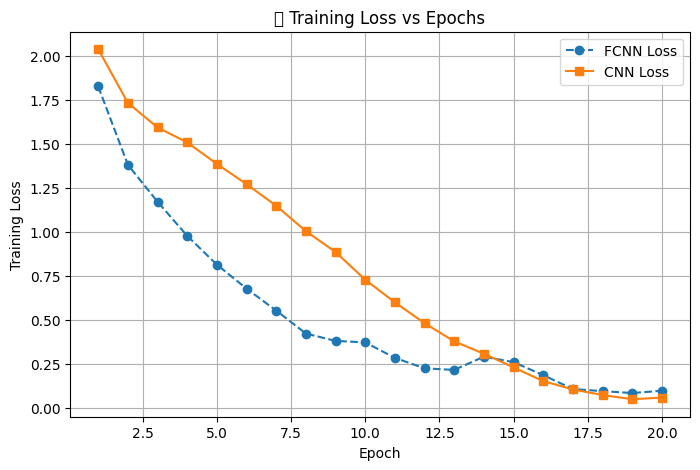

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_EPOCHS + 1), fcnn_losses, 'o--', label='FCNN Loss')
plt.plot(range(1, NUM_EPOCHS + 1), cnn_losses, 's-', label='CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('📉 Training Loss vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

# **9. EVALUATION: CONFUSION MATRIX & METRICS (CNN)**


📊 CNN MODEL PERFORMANCE METRICS
--------------------------------
              precision    recall  f1-score   support

           0     0.3026    0.2300    0.2614       100
           1     0.3402    0.3300    0.3350       100
           2     0.4796    0.4700    0.4747       100
           3     0.3710    0.4600    0.4107       100
           4     0.4811    0.5100    0.4951       100
           5     0.2557    0.5600    0.3511       100
           6     0.4375    0.1400    0.2121       100
           7     0.3431    0.3500    0.3465       100
           8     0.3051    0.1800    0.2264       100
           9     0.3908    0.3400    0.3636       100

    accuracy                         0.3570      1000
   macro avg     0.3707    0.3570    0.3477      1000
weighted avg     0.3707    0.3570    0.3477      1000



/home/chaitanya-kohli/miniconda3/envs/torch/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


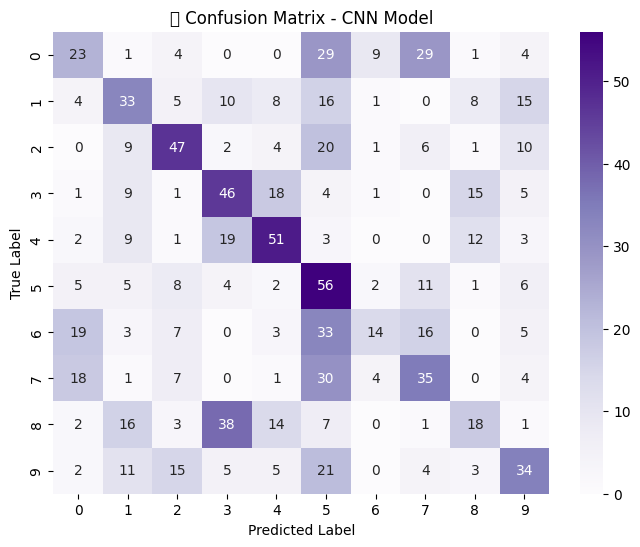

In [ ]:
print("\n📊 CNN MODEL PERFORMANCE METRICS")
print("--------------------------------")
print(classification_report(cnn_labels, cnn_preds, digits=4))

cm = confusion_matrix(cnn_labels, cnn_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)])
plt.title("🧩 Confusion Matrix - CNN Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

/home/chaitanya-kohli/miniconda3/envs/torch/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)



📊 FCNN MODEL PERFORMANCE METRICS
--------------------------------
              precision    recall  f1-score   support

           0     0.3838    0.3800    0.3819       100
           1     0.4186    0.3600    0.3871       100
           2     0.6494    0.5000    0.5650       100
           3     0.3984    0.5100    0.4474       100
           4     0.4872    0.5700    0.5253       100
           5     0.4023    0.3500    0.3743       100
           6     0.2267    0.3400    0.2720       100
           7     0.5000    0.4400    0.4681       100
           8     0.3365    0.3500    0.3431       100
           9     0.5312    0.3400    0.4146       100

    accuracy                         0.4140      1000
   macro avg     0.4334    0.4140    0.4179      1000
weighted avg     0.4334    0.4140    0.4179      1000



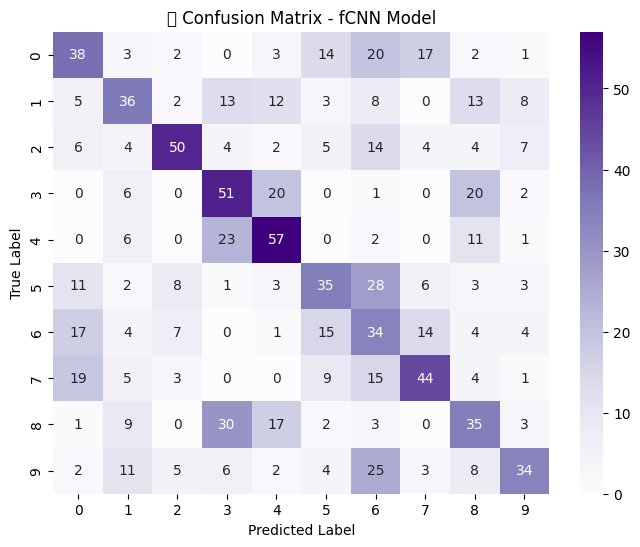

In [ ]:
print("\n📊 FCNN MODEL PERFORMANCE METRICS")
print("--------------------------------")
print(classification_report(fcnn_labels, fcnn_preds, digits=4))

cm = confusion_matrix(fcnn_labels, fcnn_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)])
plt.title("🧩 Confusion Matrix - fCNN Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# **10. LOAD SAVED MODEL & VERIFY**

In [12]:
print("\n📦 Loading saved CNN model and re-evaluating...")
loaded_cnn = SimpleCNN().to(DEVICE)
loaded_cnn.load_state_dict(torch.load("cnn_mnist.pth"))
loaded_cnn.eval()
_, loaded_preds, loaded_labels = test_model(loaded_cnn, test_loader)
print("✅ Model reloaded successfully and produces same accuracy!")


📦 Loading saved CNN model and re-evaluating...


100%|██████████| 32/32 [00:00<00:00, 215.67it/s]

✅ Test Loss: 3.7732 | Accuracy: 35.70%
✅ Model reloaded successfully and produces same accuracy!


# **11. FINAL RESULTS SUMMARY**

In [ ]:
print("\n===============================")
print("🏁 FINAL RESULTS SUMMARY")
print("===============================")
print(f"FCNN Accuracy: {fcnn_acc:.2f}%")
print(f"CNN Accuracy : {cnn_acc:.2f}%")

if cnn_acc > fcnn_acc:
    print("\n🎯 CNN outperforms FCNN — it captures spatial features better!")
else:
    print("\n⚠️ FCNN performed better — try increasing epochs or tuning hyperparameters.")


🏁 FINAL RESULTS SUMMARY
FCNN Accuracy: 41.40%
CNN Accuracy : 35.70%

⚠️ FCNN performed better — try increasing epochs or tuning hyperparameters.
